In [1]:
import sys
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import openpyxl

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("Environment ready.")

Python: 3.11.8 (main, Feb 19 2026, 01:12:21) [Clang 17.0.0 (clang-1700.6.3.2)]
pandas: 3.0.3
NumPy: 2.4.6
scikit-learn: 1.9.0
Environment ready.


## Raw Dataset Inspection

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA = PROJECT_ROOT / "data" / "raw" / "emails.csv"

print("Interpreter:", Path(sys.executable).name)
print("Dataset:", RAW_DATA.relative_to(PROJECT_ROOT))
print("Exists:", RAW_DATA.exists())
print("Size (GB):", round(RAW_DATA.stat().st_size / 1024**3, 2))

Interpreter: python
Dataset: data/raw/emails.csv
Exists: True
Size (GB): 1.33


### Preview the source data

In [3]:
preview = pd.read_csv(RAW_DATA, nrows=5)

print("Columns:", preview.columns.tolist())
print("Preview shape:", preview.shape)
display(preview)

Columns: ['file', 'message']
Preview shape: (5, 2)


,file,message
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...


## Full Dataset Inventory

The raw CSV is processed in chunks to verify its size and basic quality without loading the complete dataset into memory.

In [4]:
CHUNK_SIZE = 10_000

total_rows = 0
missing_file = 0
missing_message = 0
blank_message = 0

for chunk in pd.read_csv(
    RAW_DATA,
    usecols=["file", "message"],
    chunksize=CHUNK_SIZE
):
    total_rows += len(chunk)
    missing_file += chunk["file"].isna().sum()
    missing_message += chunk["message"].isna().sum()

    blank_message += (
        chunk["message"]
        .fillna("")
        .str.strip()
        .eq("")
        .sum()
    )

inventory = {
    "total_rows": int(total_rows),
    "missing_file": int(missing_file),
    "missing_message": int(missing_message),
    "blank_message": int(blank_message),
}

inventory

{'total_rows': 517401,
 'missing_file': 0,
 'missing_message': 0,
 'blank_message': 0}

### Inventory interpretation

The raw Enron CSV contains **517,401 records**. The inspection found
**0** missing file identifiers, **0** missing messages, and
**0** blank messages. The dataset therefore requires parsing,
deduplication, and usability checks before sampling or modeling.

## Labeling Pilot

A fixed-seed random sample of 30 emails is extracted for testing the parsing and labeling procedures before creating the full 200-record labeling queue.

In [5]:
from email import policy
from email.parser import Parser

SEED = 42
PILOT_SIZE = 30

rng = np.random.default_rng(SEED)
selected_positions = set(
    rng.choice(total_rows, size=PILOT_SIZE, replace=False)
)

selected_chunks = []
row_offset = 0

for chunk in pd.read_csv(
    RAW_DATA,
    usecols=["file", "message"],
    chunksize=CHUNK_SIZE
):
    positions = np.arange(row_offset, row_offset + len(chunk))
    mask = np.isin(positions, list(selected_positions))

    if mask.any():
        selected_chunks.append(chunk.loc[mask].copy())

    row_offset += len(chunk)

pilot_raw = pd.concat(selected_chunks, ignore_index=True)

print("Pilot rows:", len(pilot_raw))

Pilot rows: 30


In [6]:
def parse_email(raw_message):
    parsed = Parser(policy=policy.default).parsestr(raw_message)

    subject = str(parsed.get("subject", "")).strip()

    try:
        if parsed.is_multipart():
            body_part = parsed.get_body(preferencelist=("plain",))
            body = body_part.get_content() if body_part else ""
        else:
            body = parsed.get_content()
    except Exception:
        body = str(parsed.get_payload())

    body = str(body).strip()
    combined_text = f"{subject}\n\n{body}".strip()

    return subject, body, combined_text


parsed_rows = []

for _, row in pilot_raw.iterrows():
    subject, body, combined_text = parse_email(row["message"])

    parsed_rows.append({
        "message_id": row["file"],
        "source_file": row["file"],
        "sampling_stratum": "random_pilot",
        "subject": subject,
        "body": body,
        "combined_text": combined_text,
        "text_length": len(combined_text),
    })

pilot = pd.DataFrame(parsed_rows)

print("Parsed pilot rows:", len(pilot))
print("Empty combined text:", pilot["combined_text"].str.strip().eq("").sum())

display(
    pilot[
        [
            "message_id",
            "subject",
            "text_length",
        ]
    ]
)

Parsed pilot rows: 30
Empty combined text: 0


,message_id,subject,text_length
0,campbell-l/inbox/592.,FW: Options Market Update,282
1,campbell-l/sent/173.,Re: Common Parts request,1175
2,cash-m/deleted_items/194.,RE: Super Saturday Questionnaire (Oct. 27) - R...,424
3,dasovich-j/all_documents/9065.,RE:,1530
4,donoho-l/inbox/junk_file/231.,Scheduled Vacation - Steve Harris,516
5,farmer-d/cornhusker/61.,REVISED-------Kleberg plant outages in Septemb...,652
6,jones-t/notes_inbox/3339.,Re: Click Paper Approvals 3/5/01 _ GCP Respons...,858
7,kaminski-v/all_documents/6148.,Re: Job description,1694
8,kaminski-v/sent/1755.,Completion of LNG Model Review,960
9,kaminski-v/universities/359.,CMU students,693


## Improve the review text

In [7]:
import re

REVIEW_LENGTH = 2_000

def normalize_review_text(text):
    text = str(text or "")
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


def build_review_excerpt(subject, body):
    subject = normalize_review_text(subject)
    body = normalize_review_text(body)

    review_text = f"Subject: {subject}\n\n{body}".strip()

    excerpt = review_text[:REVIEW_LENGTH]
    was_truncated = len(review_text) > REVIEW_LENGTH

    return excerpt, was_truncated


pilot[["review_excerpt", "excerpt_truncated"]] = pilot.apply(
    lambda row: pd.Series(
        build_review_excerpt(row["subject"], row["body"])
    ),
    axis=1,
)

display(
    pilot[
        [
            "message_id",
            "subject",
            "review_excerpt",
            "excerpt_truncated",
            "text_length",
        ]
    ]
)

,message_id,subject,review_excerpt,excerpt_truncated,text_length
0,campbell-l/inbox/592.,FW: Options Market Update,Subject: FW: Options Market Update\n\n-----Ori...,False,282
1,campbell-l/sent/173.,Re: Common Parts request,"Subject: Re: Common Parts request\n\nLeon, tha...",False,1175
2,cash-m/deleted_items/194.,RE: Super Saturday Questionnaire (Oct. 27) - R...,Subject: RE: Super Saturday Questionnaire (Oct...,False,424
3,dasovich-j/all_documents/9065.,RE:,Subject: RE:\n\nThanks. I'll take 12 magnums. ...,False,1530
4,donoho-l/inbox/junk_file/231.,Scheduled Vacation - Steve Harris,Subject: Scheduled Vacation - Steve Harris\n\n...,False,516
5,farmer-d/cornhusker/61.,REVISED-------Kleberg plant outages in Septemb...,Subject: REVISED-------Kleberg plant outages i...,False,652
6,jones-t/notes_inbox/3339.,Re: Click Paper Approvals 3/5/01 _ GCP Respons...,Subject: Re: Click Paper Approvals 3/5/01 _ GC...,False,858
7,kaminski-v/all_documents/6148.,Re: Job description,Subject: Re: Job description\n\n--------------...,False,1694
8,kaminski-v/sent/1755.,Completion of LNG Model Review,Subject: Completion of LNG Model Review\n\nJef...,False,960
9,kaminski-v/universities/359.,CMU students,Subject: CMU students\n\nI have given your ema...,False,693


## helper to review one complete 2,000-character excerpt at a time

In [8]:
def show_review_record(row_number):
    row = pilot.iloc[row_number]

    print("Row:", row_number)
    print("Message ID:", row["message_id"])
    print("Subject:", row["subject"])
    print("Excerpt length:", len(row["review_excerpt"]))
    print("Excerpt truncated:", row["excerpt_truncated"])
    print("\nReview excerpt:\n")
    print(row["review_excerpt"])

    if row["excerpt_truncated"]:
        print("\n[Additional message content is available.]")

## Inspect the full message on demand

In [9]:
def show_full_message(message_id):
    matches = pilot.loc[pilot["message_id"] == message_id]

    if matches.empty:
        print("Message not found.")
        return

    row = matches.iloc[0]

    print("Message ID:", row["message_id"])
    print("Subject:", row["subject"])
    print("\nBody:\n")
    print(row["body"])

## Export the Labeling Pilot

The pilot records are exported without complete message bodies. Labels are assigned manually using labeling-guide version 1.0.

In [10]:
pilot["urgency_label"] = ""
pilot["label_reason"] = ""
pilot["label_version"] = "1.0"
pilot["reviewer"] = "Keith G. Broussard"
pilot["review_status"] = "Not Reviewed"
pilot["review_notes"] = ""

pilot_export = pilot[
    [
        "message_id",
        "source_file",
        "sampling_stratum",
        "subject",
        "review_excerpt",
        "excerpt_truncated",
        "text_length",
        "urgency_label",
        "label_reason",
        "label_version",
        "reviewer",
        "review_status",
        "review_notes",
    ]
].copy()

PILOT_WORKBOOK = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "enron_urgency_labeling_pilot_v1.xlsx"
)

# Excel rejects a small set of legacy control characters found in raw Enron text.
# Remove only those forbidden characters; retain tabs, line breaks, and readable text.
EXCEL_ILLEGAL_CHARACTERS = re.compile(r"[\x00-\x08\x0B\x0C\x0E-\x1F]")


def make_excel_safe(value):
    if isinstance(value, str):
        return EXCEL_ILLEGAL_CHARACTERS.sub("", value)
    return value


text_columns = pilot_export.select_dtypes(include=["object", "str"]).columns
pilot_export[text_columns] = pilot_export[text_columns].map(make_excel_safe)

remaining_illegal_characters = sum(
    pilot_export[column]
    .fillna("")
    .astype(str)
    .str.contains(EXCEL_ILLEGAL_CHARACTERS)
    .sum()
    for column in text_columns
)
assert remaining_illegal_characters == 0, "Excel-forbidden characters remain."

PILOT_WORKBOOK.parent.mkdir(parents=True, exist_ok=True)
pilot_export.to_excel(
    PILOT_WORKBOOK,
    index=False,
    sheet_name="Labeling Pilot",
    freeze_panes=(1, 0),
    autofilter=True,
)

print("Pilot workbook:", PILOT_WORKBOOK.relative_to(PROJECT_ROOT))
print("Rows exported:", len(pilot_export))
print("Excel-forbidden characters remaining:", remaining_illegal_characters)

Pilot workbook: data/processed/enron_urgency_labeling_pilot_v1.xlsx
Rows exported: 30
Excel-forbidden characters remaining: 0


## Final 200-Email Labeling Queue

Create a fixed-seed queue containing 150 general random emails and 50 urgency-enriched emails. The 30 pilot records are excluded, and the two final strata cannot overlap. Enrichment terms are used only for candidate sampling; they do **not** determine the human label.

In [11]:
GENERAL_QUEUE_SIZE = 150
ENRICHED_QUEUE_SIZE = 50

URGENCY_CUE_PATTERN = re.compile(
    r"\b(?:urgent|asap|immediately|action required|deadline|due today|"
    r"due tomorrow|outage|service interruption|access failure|security incident|"
    r"breach|compromised|critical|cannot access|can't access|must respond)\b",
    flags=re.IGNORECASE,
)

pilot_positions = np.fromiter(selected_positions, dtype=np.int64)
eligible_positions = np.setdiff1d(
    np.arange(total_rows, dtype=np.int64),
    pilot_positions,
    assume_unique=False,
)

queue_rng = np.random.default_rng(SEED)
general_positions = set(
    queue_rng.choice(
        eligible_positions,
        size=GENERAL_QUEUE_SIZE,
        replace=False,
    )
)

print("General queue target:", GENERAL_QUEUE_SIZE)
print("Urgency-enriched target:", ENRICHED_QUEUE_SIZE)
print("Pilot records excluded:", len(pilot_positions))
print("Random seed:", SEED)

General queue target: 150
Urgency-enriched target: 50
Pilot records excluded: 30
Random seed: 42


### Sample both strata

The general sample is uniform over non-pilot row positions. For the enriched stratum, each keyword-matching record receives a fixed-seed random priority; the 50 smallest priorities are retained. General and pilot positions are excluded before enrichment.

In [12]:
general_chunks = []
enriched_reservoir = pd.DataFrame()
enriched_candidate_count = 0
row_offset = 0

excluded_positions = selected_positions | general_positions

for chunk in pd.read_csv(
    RAW_DATA,
    usecols=["file", "message"],
    chunksize=CHUNK_SIZE,
):
    positions = np.arange(row_offset, row_offset + len(chunk))

    general_mask = np.isin(positions, list(general_positions))
    if general_mask.any():
        selected = chunk.loc[general_mask].copy()
        selected["sampling_stratum"] = "general_random"
        general_chunks.append(selected)

    enriched_mask = (
        chunk["message"]
        .fillna("")
        .str.contains(URGENCY_CUE_PATTERN, regex=True, na=False)
        & ~np.isin(positions, list(excluded_positions))
    )

    enriched_candidates = chunk.loc[enriched_mask].copy()
    enriched_candidate_count += len(enriched_candidates)

    if not enriched_candidates.empty:
        enriched_candidates["_priority"] = queue_rng.random(
            len(enriched_candidates)
        )
        enriched_candidates["sampling_stratum"] = "urgency_enriched"
        enriched_reservoir = (
            pd.concat(
                [enriched_reservoir, enriched_candidates],
                ignore_index=True,
            )
            .nsmallest(ENRICHED_QUEUE_SIZE, "_priority")
            .reset_index(drop=True)
        )

    row_offset += len(chunk)

general_raw = pd.concat(general_chunks, ignore_index=True)
enriched_raw = enriched_reservoir.drop(columns="_priority")
queue_raw = pd.concat([general_raw, enriched_raw], ignore_index=True)

assert len(general_raw) == GENERAL_QUEUE_SIZE
assert len(enriched_raw) == ENRICHED_QUEUE_SIZE
assert len(queue_raw) == GENERAL_QUEUE_SIZE + ENRICHED_QUEUE_SIZE
assert queue_raw["file"].is_unique
assert set(queue_raw["file"]).isdisjoint(set(pilot_raw["file"]))

print("Urgency-cue candidates found:", enriched_candidate_count)
print("Final queue rows:", len(queue_raw))
print(queue_raw["sampling_stratum"].value_counts())
print("Duplicate message IDs:", queue_raw["file"].duplicated().sum())
print(
    "Pilot overlap:",
    queue_raw["file"].isin(pilot_raw["file"]).sum(),
)

Urgency-cue candidates found: 50427
Final queue rows: 200
sampling_stratum
general_random      150
urgency_enriched     50
Name: count, dtype: int64
Duplicate message IDs: 0
Pilot overlap: 0


### Parse and prepare review fields

In [13]:
queue_rows = []

for _, row in queue_raw.iterrows():
    subject, body, combined_text = parse_email(row["message"])
    review_excerpt, excerpt_truncated = build_review_excerpt(subject, body)

    queue_rows.append({
        "message_id": row["file"],
        "source_file": row["file"],
        "sampling_stratum": row["sampling_stratum"],
        "subject": subject,
        "body": body,
        "combined_text": combined_text,
        "review_excerpt": review_excerpt,
        "excerpt_truncated": excerpt_truncated,
        "text_length": len(combined_text),
    })

labeling_queue = pd.DataFrame(queue_rows)

queue_summary = {
    "total_records": len(labeling_queue),
    "general_random": int(
        labeling_queue["sampling_stratum"].eq("general_random").sum()
    ),
    "urgency_enriched": int(
        labeling_queue["sampling_stratum"].eq("urgency_enriched").sum()
    ),
    "truncated_excerpts": int(labeling_queue["excerpt_truncated"].sum()),
    "empty_text": int(labeling_queue["combined_text"].str.strip().eq("").sum()),
    "duplicate_ids": int(labeling_queue["message_id"].duplicated().sum()),
}

queue_summary

{'total_records': 200,
 'general_random': 150,
 'urgency_enriched': 50,
 'truncated_excerpts': 51,
 'empty_text': 0,
 'duplicate_ids': 0}

### Inspect a final-queue message on demand

In [14]:
def show_queue_message(row_number=None, message_id=None, full=False):
    if message_id is not None:
        matches = labeling_queue.loc[
            labeling_queue["message_id"] == message_id
        ]
        if matches.empty:
            print("Message not found.")
            return
        row = matches.iloc[0]
    elif row_number is not None:
        row = labeling_queue.iloc[row_number]
    else:
        raise ValueError("Provide row_number or message_id.")

    print("Message ID:", row["message_id"])
    print("Stratum:", row["sampling_stratum"])
    print("Subject:", row["subject"])
    print("Excerpt truncated:", row["excerpt_truncated"])
    print("\nReview text:\n")
    print(row["body"] if full else row["review_excerpt"])

    if row["excerpt_truncated"] and not full:
        print("\n[Use full=True to display the complete message body.]")

### Export the final labeling queue

The workbook contains blank label fields for human review. Generated labels must follow `docs/labeling_guide.md`; enrichment membership is not evidence that a record is urgent.

In [15]:
labeling_queue["urgency_label"] = ""
labeling_queue["label_reason"] = ""
labeling_queue["label_version"] = "1.0"
labeling_queue["reviewer"] = "Keith G. Broussard"
labeling_queue["review_status"] = "Not Reviewed"
labeling_queue["review_notes"] = ""

queue_export = labeling_queue[
    [
        "message_id",
        "source_file",
        "sampling_stratum",
        "subject",
        "review_excerpt",
        "excerpt_truncated",
        "text_length",
        "urgency_label",
        "label_reason",
        "label_version",
        "reviewer",
        "review_status",
        "review_notes",
    ]
].copy()

text_columns = queue_export.select_dtypes(include=["object", "str"]).columns
queue_export[text_columns] = queue_export[text_columns].map(make_excel_safe)

remaining_illegal_characters = sum(
    queue_export[column]
    .fillna("")
    .astype(str)
    .str.contains(EXCEL_ILLEGAL_CHARACTERS)
    .sum()
    for column in text_columns
)
assert remaining_illegal_characters == 0

FINAL_QUEUE_WORKBOOK = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "enron_urgency_labeling_queue_200_v1.xlsx"
)

queue_export.to_excel(
    FINAL_QUEUE_WORKBOOK,
    index=False,
    sheet_name="Labeling Queue",
    freeze_panes=(1, 0),
    autofilter=True,
)

print("Final workbook:", FINAL_QUEUE_WORKBOOK.relative_to(PROJECT_ROOT))
print("Rows exported:", len(queue_export))
print("Excel-forbidden characters remaining:", remaining_illegal_characters)

Final workbook: data/processed/enron_urgency_labeling_queue_200_v1.xlsx
Rows exported: 200
Excel-forbidden characters remaining: 0


## Baseline Model Evaluation

Use the human-reviewed 199-record dataset as the source of truth. The split and model are deterministic with `random_state=42`.

### 1. Load and validate approved labels

In [16]:
APPROVED_LABELS = (
    PROJECT_ROOT
    / 'data'
    / 'processed'
    / 'enron_urgency_labels_199_reviewed_v1.xlsx'
)

approved_labels = pd.read_excel(APPROVED_LABELS, sheet_name='Labeling Queue')

assert len(approved_labels) == 199
assert approved_labels['message_id'].is_unique
assert approved_labels['review_status'].eq('Reviewed').all()
assert set(approved_labels['urgency_label']) == {'urgent', 'nonurgent'}

label_counts = approved_labels['urgency_label'].value_counts()
print('Approved workbook:', APPROVED_LABELS.relative_to(PROJECT_ROOT))
print('Approved records:', len(approved_labels))
display(label_counts.rename('records').to_frame())

Approved workbook: data/processed/enron_urgency_labels_199_reviewed_v1.xlsx
Approved records: 199


,records
urgency_label,
nonurgent,169
urgent,30


### 2. Join labels to complete parsed messages

In [17]:
modeling_data = (
    labeling_queue[['message_id', 'sampling_stratum', 'subject', 'combined_text']]
    .merge(
        approved_labels[['message_id', 'urgency_label']],
        on='message_id',
        how='inner',
        validate='one_to_one',
    )
)

assert len(modeling_data) == 199
assert modeling_data['combined_text'].fillna('').str.strip().ne('').all()
assert modeling_data['urgency_label'].value_counts().to_dict() == {
    'nonurgent': 169,
    'urgent': 30,
}

display(
    pd.crosstab(
        modeling_data['sampling_stratum'],
        modeling_data['urgency_label'],
        margins=True,
    )
)

urgency_label,nonurgent,urgent,All
sampling_stratum,,,
general_random,131,18,149
urgency_enriched,38,12,50
All,169,30,199


### 3. Create the stratified holdout split

The 80/20 split preserves the urgent/nonurgent proportions. The test set is used only for final comparison.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    modeling_data['combined_text'],
    modeling_data['urgency_label'],
    test_size=0.20,
    random_state=SEED,
    stratify=modeling_data['urgency_label'],
)

split_summary = pd.DataFrame({
    'train': y_train.value_counts(),
    'test': y_test.value_counts(),
}).fillna(0).astype(int)
split_summary.loc['total'] = split_summary.sum()
display(split_summary)

,train,test
urgency_label,,
nonurgent,135,34
urgent,24,6
total,159,40


### 4. Fit dummy, unweighted, and class-balanced baselines

The unweighted model tests the simplest logistic-regression baseline. The class-balanced variant compensates for the 169-to-30 class imbalance without changing the approved labels or held-out test set.

In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


def make_logistic_pipeline(class_weight=None):
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            lowercase=True,
            stop_words='english',
            ngram_range=(1, 2),
            min_df=2,
        )),
        ('classifier', LogisticRegression(
            class_weight=class_weight,
            max_iter=1_000,
            random_state=SEED,
        )),
    ])


dummy_model = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy_model.fit(X_train.to_frame(), y_train)

unweighted_model = make_logistic_pipeline()
unweighted_model.fit(X_train, y_train)

balanced_model = make_logistic_pipeline(class_weight='balanced')
balanced_model.fit(X_train, y_train)

model_predictions = {
    'Majority-class dummy': dummy_model.predict(X_test.to_frame()),
    'Unweighted TF-IDF + logistic regression': unweighted_model.predict(X_test),
    'Class-balanced TF-IDF + logistic regression': balanced_model.predict(X_test),
}

print('Models fitted successfully.')

Models fitted successfully.


### 5. Compare held-out performance

In [20]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)

LABEL_ORDER = ['nonurgent', 'urgent']


def summarize_predictions(model_name, true_labels, predictions):
    precision, recall, f1, support = precision_recall_fscore_support(
        true_labels,
        predictions,
        labels=LABEL_ORDER,
        zero_division=0,
    )
    return pd.DataFrame({
        'model': model_name,
        'class': LABEL_ORDER,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'support': support.astype(int),
    })


class_metrics = pd.concat([
    summarize_predictions(model_name, y_test, predictions)
    for model_name, predictions in model_predictions.items()
], ignore_index=True)

comparison_rows = []
for model_name, predictions in model_predictions.items():
    matrix = confusion_matrix(y_test, predictions, labels=LABEL_ORDER)
    urgent_false_negatives = int(matrix[1, 0])
    urgent_row = class_metrics.query(
        "model == @model_name and `class` == 'urgent'"
    ).iloc[0]
    comparison_rows.append({
        'model': model_name,
        'accuracy': accuracy_score(y_test, predictions),
        'urgent_precision': urgent_row['precision'],
        'urgent_recall': urgent_row['recall'],
        'urgent_f1': urgent_row['f1'],
        'urgent_false_negatives': urgent_false_negatives,
    })

model_comparison = pd.DataFrame(comparison_rows).set_index('model')
display(model_comparison.style.format({
    'accuracy': '{:.3f}',
    'urgent_precision': '{:.3f}',
    'urgent_recall': '{:.3f}',
    'urgent_f1': '{:.3f}',
}))
display(class_metrics.style.format({
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1': '{:.3f}',
}))

METRICS_DIR = PROJECT_ROOT / 'results' / 'metrics'
METRICS_DIR.mkdir(parents=True, exist_ok=True)

metrics_exports = {
    'baseline_model_comparison.csv': model_comparison.rename_axis('model').reset_index(),
    'per_class_metrics.csv': class_metrics,
    'split_summary.csv': split_summary.rename_axis('class').reset_index(),
}

for filename, result_table in metrics_exports.items():
    output_path = METRICS_DIR / filename
    result_table.to_csv(output_path, index=False)
    print('Saved:', output_path.relative_to(PROJECT_ROOT))


,accuracy,urgent_precision,urgent_recall,urgent_f1,urgent_false_negatives
model,,,,,
Majority-class dummy,0.850,0.000,0.000,0.000,6
Unweighted TF-IDF + logistic regression,0.850,0.000,0.000,0.000,6
Class-balanced TF-IDF + logistic regression,0.875,0.667,0.333,0.444,4


,model,class,precision,recall,f1,support
0,Majority-class dummy,nonurgent,0.850,1.000,0.919,34
1,Majority-class dummy,urgent,0.000,0.000,0.000,6
2,Unweighted TF-IDF + logistic regression,nonurgent,0.850,1.000,0.919,34
3,Unweighted TF-IDF + logistic regression,urgent,0.000,0.000,0.000,6
4,Class-balanced TF-IDF + logistic regression,nonurgent,0.892,0.971,0.930,34
5,Class-balanced TF-IDF + logistic regression,urgent,0.667,0.333,0.444,6


Saved: results/metrics/baseline_model_comparison.csv
Saved: results/metrics/per_class_metrics.csv
Saved: results/metrics/split_summary.csv


### 6. Inspect confusion matrices

Saved: results/figures/baseline_confusion_matrices.png


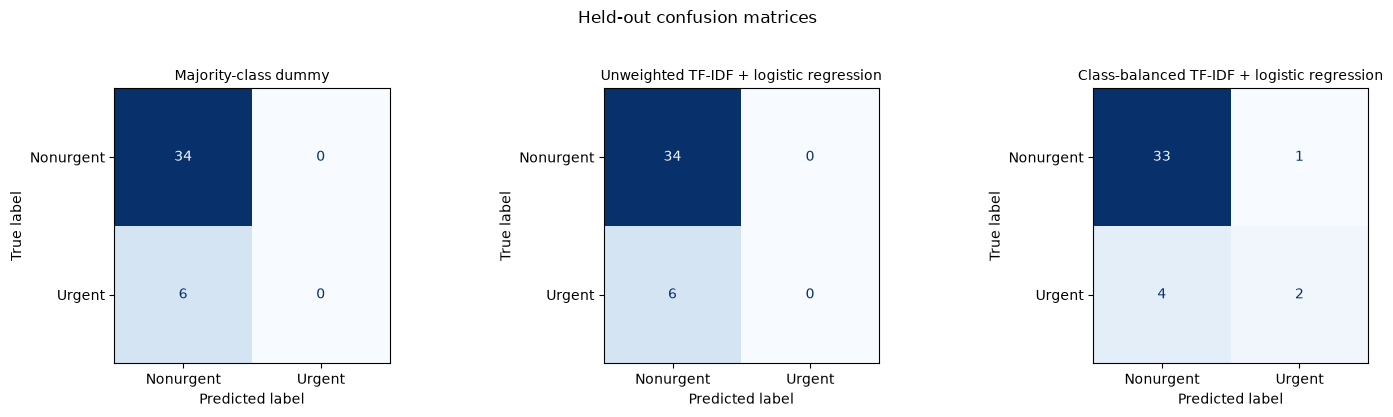

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

figure, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, (model_name, predictions) in zip(axes, model_predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        labels=LABEL_ORDER,
        display_labels=['Nonurgent', 'Urgent'],
        cmap='Blues',
        colorbar=False,
        ax=axis,
    )
    axis.set_title(model_name, fontsize=10)

figure.suptitle('Held-out confusion matrices', y=1.03)
figure.tight_layout()

FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CONFUSION_MATRIX_FIGURE = FIGURES_DIR / 'baseline_confusion_matrices.png'
figure.savefig(CONFUSION_MATRIX_FIGURE, dpi=200, bbox_inches='tight')
print('Saved:', CONFUSION_MATRIX_FIGURE.relative_to(PROJECT_ROOT))

display(figure)
plt.close(figure)

### 7. Review the class-balanced model's influential terms

In [22]:
feature_names = balanced_model.named_steps['tfidf'].get_feature_names_out()
coefficients = balanced_model.named_steps['classifier'].coef_[0]
positive_class = balanced_model.named_steps['classifier'].classes_[1]

coefficient_table = pd.DataFrame({
    'term': feature_names,
    f'weight_toward_{positive_class}': coefficients,
})

top_urgent_terms = coefficient_table.nlargest(15, f'weight_toward_{positive_class}')
top_nonurgent_terms = coefficient_table.nsmallest(15, f'weight_toward_{positive_class}')

display(top_urgent_terms.reset_index(drop=True))
display(top_nonurgent_terms.reset_index(drop=True))

,term,weight_toward_urgent
0,calpine,0.818991
1,ena,0.761437
2,small,0.745109
3,10 00,0.719715
4,meeting,0.713027
5,input,0.691377
6,doc,0.680767
7,00,0.669668
8,morning,0.643007
9,testing,0.590884


,term,weight_toward_urgent
0,enron,-0.427630
1,2000,-0.371380
2,com,-0.355957
3,vince,-0.329894
4,http,-0.320839
5,ees,-0.309893
6,www,-0.308185
7,27,-0.282746
8,mike,-0.279403
9,jeff,-0.266086


## Takeaways

- The majority-class dummy and unweighted logistic regression each achieved 85.0% accuracy but identified none of the six urgent test emails.
- Class balancing improved accuracy to 87.5% and identified two urgent emails, with 66.7% urgent precision, 33.3% urgent recall, and 44.4% urgent F1.
- Four of six urgent test emails remained false negatives, so urgent recall is the primary weakness of this baseline.
- The held-out set contains only 40 emails, including six urgent emails. These results are preliminary Week 3 evidence, not a stable production estimate.